<a href="https://colab.research.google.com/github/Sharu-052897/deep-learning/blob/main/MLP_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import tensorflow as tf
import keras_tuner as kt

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
data = fetch_california_housing()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 8)
y shape: (20640,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def build_model(hp):

    model = keras.Sequential()

    # Input layer
    model.add(
        layers.Dense(
            64,
            activation='relu',
            input_shape=(X_train.shape[1],)
        )
    )

    # Number of hidden layers
    num_layers = hp.Int(
        'num_layers',
        min_value=1,
        max_value=3,
        step=1
    )

    for i in range(num_layers):

        model.add(
            layers.Dense(
                units=hp.Int(
                    f'units_{i}',
                    min_value=32,
                    max_value=128,
                    step=32
                ),
                activation='relu'
            )
        )

        # Dropout rate
        dropout_rate = hp.Float(
            f'dropout_{i}',
            min_value=0.0,
            max_value=0.5,
            step=0.1
        )

        model.add(layers.Dropout(dropout_rate))

    # Output layer
    model.add(layers.Dense(1))

    # Learning rate
    learning_rate = hp.Choice(
        'learning_rate',
        values=[0.001, 0.0005, 0.0001]
    )

    # Optimizer
    optimizer_name = hp.Choice(
        'optimizer',
        values=['adam', 'sgd']
    )

    if optimizer_name == 'adam':
        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate
        )
    else:
        optimizer = keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    # Compile
    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    directory='tuner_results',
    project_name='california_housing'
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
tuner.search(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=10
)

Trial 10 Complete [00h 00m 40s]
val_loss: 0.32947519421577454

Best val_loss So Far: 0.3170337975025177
Total elapsed time: 00h 05m 00s


In [ ]:
best_hps = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

print("Best number of layers:",
      best_hps.get('num_layers'))

print("Best learning rate:",
      best_hps.get('learning_rate'))

print("Best optimizer:",
      best_hps.get('optimizer'))

for i in range(best_hps.get('num_layers')):
    print(
        "Layer", i + 1,
        "units:",
        best_hps.get(f'units_{i}')
    )

    print(
        "Layer", i + 1,
        "dropout:",
        best_hps.get(f'dropout_{i}')
    )

Best number of layers: 2
Best learning rate: 0.001
Best optimizer: adam
Layer 1 units: 96
Layer 1 dropout: 0.1
Layer 2 units: 96
Layer 2 dropout: 0.2


In [ ]:
best_model = tuner.hypermodel.build(best_hps)

best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 96)             │         6,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,225 (63.38 KB)

 Trainable params: 16,225 (63.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = best_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=10,
    validation_split=0.2
)

Epoch 1/10
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3555 - mae: 0.4162 - val_loss: 0.3311 - val_mae: 0.3901
Epoch 2/10
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3389 - mae: 0.4053 - val_loss: 0.3365 - val_mae: 0.3886
Epoch 3/10
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3297 - mae: 0.3988 - val_loss: 0.3598 - val_mae: 0.4265
Epoch 4/10
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3256 - mae: 0.3957 - val_loss: 0.3300 - val_mae: 0.3927
Epoch 5/10
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3641 - mae: 0.3912 - val_loss: 0.3090 - val_mae: 0.3811
Epoch 6/10
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3148 - mae: 0.3861 - val_loss: 0.3141 - val_mae: 0.3797
Epoch 7/10
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3066 - mae: 0.3817 - val_loss: 0.3234 - val_mae: 0.3813
Epoch 8/10
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3005 - mae: 0.3785 - val_loss: 0.3079 - val_mae: 0.3781
Epoch 9/10
1321/1321 ━━━━━━━━━━━━━━━━━━━

In [ ]:
loss, mae = best_model.evaluate(
    X_test,
    y_test
)

print("Best Model MSE:", loss)
print("Best Model MAE:", mae)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2926 - mae: 0.3766
Best Model MSE: 0.29262155294418335
Best Model MAE: 0.3766437768936157


In [ ]:
predictions = best_model.predict(X_test)

print("Actual values:")
print(y_test[:5])

print("\nPredicted values:")
print(predictions[:5].flatten())

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Actual values:
[0.477   0.458   5.00001 2.186   2.78   ]

Predicted values:
[0.59234047 1.0434116  4.0216637  2.677026   2.4875474 ]


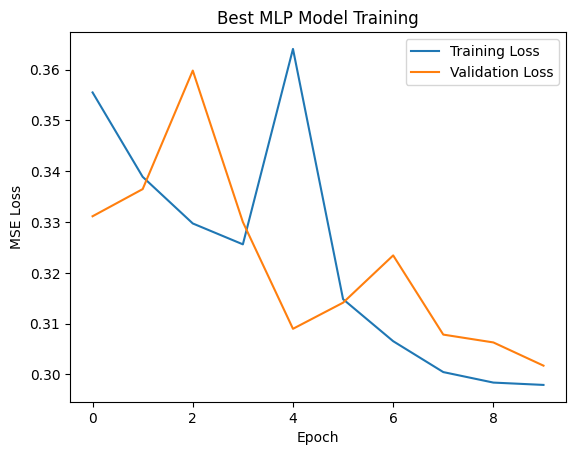

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Best MLP Model Training")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()